# Machine Learning Masterclass - Puesta en Producción
## Pipeline Industrial: Train → Artefactos → Producción Simulada

**Autor:** Josef Rodríguez

Dataset: https://www.kaggle.com/c/GiveMeSomeCredit/data

## 1. Importar librerías
Cargamos las librerías necesarias para el pipeline de Machine Learning.

In [62]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve

from lightgbm import LGBMClassifier

import joblib
import json
import os


## 2. Cargar dataset

In [63]:

url = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/credit_dataset_temporal.csv"

df = pd.read_csv(url)

df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,dataset,fecha_simulada,periodo
0,1,1.0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,train,2018-01-01 00:00:00,201801
1,2,0.0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,train,2018-01-01 01:00:00,201801
2,3,0.0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,train,2018-01-01 02:00:00,201801
3,4,0.0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,train,2018-01-01 03:00:00,201801
4,5,0.0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,train,2018-01-01 04:00:00,201801


In [87]:
df = df.dropna(subset=["SeriousDlqin2yrs"])

In [88]:
df["SeriousDlqin2yrs"].isna().sum()

np.int64(0)

## Corrección de la variable temporal

El dataset contiene una columna de periodo generada artificialmente.

Para evitar una expansión temporal incorrecta, reconstruimos la variable temporal usando meses consecutivos.

In [89]:
n = len(df)

months = pd.date_range(
    start="2018-01-01",
    periods=60,
    freq="MS"
)

df["fecha_simulada"] = np.tile(months, int(np.ceil(n/60)))[:n]

df["periodo"] = df["fecha_simulada"].dt.strftime("%Y%m").astype(int)

In [90]:
print("Periodo mínimo:", df["periodo"].min())
print("Periodo máximo:", df["periodo"].max())

Periodo mínimo: 201801
Periodo máximo: 202212


## 3. Exploración inicial

In [91]:

df.shape


(150000, 15)

In [92]:
print("Periodos disponibles:")
print(df["periodo"].unique()[:100])

Periodos disponibles:
[201801 201802 201803 201804 201805 201806 201807 201808 201809 201810
 201811 201812 201901 201902 201903 201904 201905 201906 201907 201908
 201909 201910 201911 201912 202001 202002 202003 202004 202005 202006
 202007 202008 202009 202010 202011 202012 202101 202102 202103 202104
 202105 202106 202107 202108 202109 202110 202111 202112 202201 202202
 202203 202204 202205 202206 202207 202208 202209 202210 202211 202212]


In [93]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Unnamed: 0                            150000 non-null  int64         
 1   SeriousDlqin2yrs                      150000 non-null  float64       
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64       
 3   age                                   150000 non-null  int64         
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64         
 5   DebtRatio                             150000 non-null  float64       
 6   MonthlyIncome                         120269 non-null  float64       
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64         
 8   NumberOfTimes90DaysLate               150000 non-null  int64         
 9   NumberRealEstateLoansOrLines          150000 non-null  int64         


In [94]:

df.isna().mean().sort_values(ascending=False)


MonthlyIncome                           0.198207
NumberOfDependents                      0.026160
Unnamed: 0                              0.000000
SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dataset                                 0.000000
fecha_simulada                          0.000000
periodo                                 0.000000
dtype: float64

## 4. Distribución del target

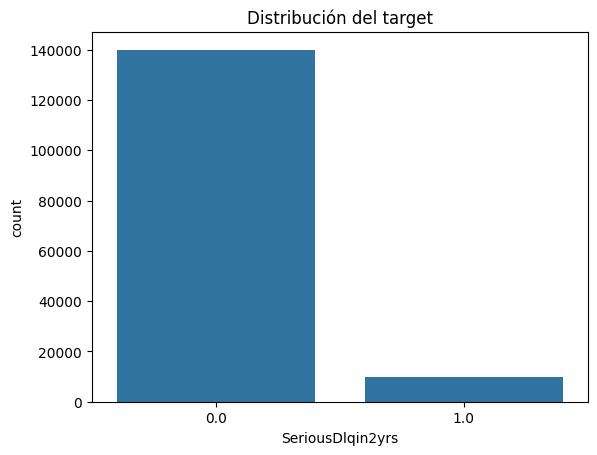

In [95]:

sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Distribución del target")
plt.show()


## 5. Análisis temporal

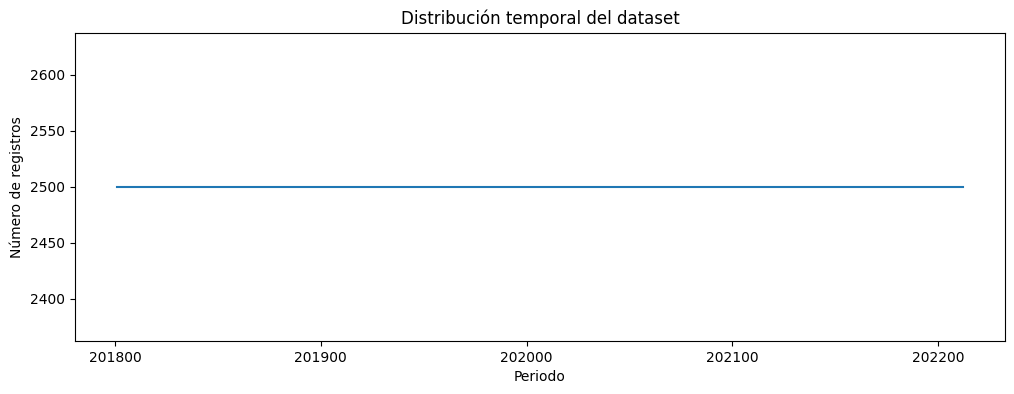

In [96]:

df.groupby("periodo").size().plot(figsize=(12,4))

plt.title("Distribución temporal del dataset")

plt.xlabel("Periodo")
plt.ylabel("Número de registros")

plt.show()

## 6. Definir variables

In [97]:

target = "SeriousDlqin2yrs"

features = [
    c for c in df.columns
    if c not in ["fecha_simulada","periodo","dataset","Unnamed: 0",target]
]

In [175]:
features

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

## 7. Split temporal

In [98]:
train = df[df.periodo <= 201912]

test = df[(df.periodo > 201912) & (df.periodo <= 202012)]

oot = df[df.periodo > 202012]

train.shape, test.shape, oot.shape


((60000, 15), (30000, 15), (60000, 15))

In [174]:
records_period = oot.groupby("periodo").size().reset_index(name="n_registros")

records_period

,periodo,n_registros
0,202101,2500
1,202102,2500
2,202103,2500
3,202104,2500
4,202105,2500
5,202106,2500
6,202107,2500
7,202108,2500
8,202109,2500
9,202110,2500


In [99]:
# eliminar filas con target faltante
train = train.dropna(subset=[target])

X_train = train[features]
y_train = train[target]

## 8. Separar X e y

In [100]:

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

X_oot = oot[features]
y_oot = oot[target]


## 9. Pipeline de transformación

In [101]:

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [102]:

pipeline.fit(X_train)

X_train_t = pipeline.transform(X_train)
X_test_t = pipeline.transform(X_test)
X_oot_t = pipeline.transform(X_oot)


In [103]:
X_train.dtypes

RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## 10. Entrenamiento del modelo

In [104]:

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train_t, y_train)


[LightGBM] [Info] Number of positive: 3989, number of negative: 56011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066483 -> initscore=-2.642008
[LightGBM] [Info] Start training from score -2.642008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [105]:
print("NaN y_train:", y_train.isna().sum())
print("NaN y_test:", y_test.isna().sum())
print("NaN y_oot:", y_oot.isna().sum())

NaN y_train: 0
NaN y_test: 0
NaN y_oot: 0


## 11. Evaluación del modelo

In [106]:
# Probabilidades
train["score"] = model.predict_proba(X_train_t)[:,1]
test["score"] = model.predict_proba(X_test_t)[:,1]
oot["score"] = model.predict_proba(X_oot_t)[:,1]

# OOT con target disponible
oot_eval = oot[~oot[target].isna()]

# Métricas
auc_train = roc_auc_score(y_train, train["score"])
auc_test = roc_auc_score(y_test, test["score"])
auc_oot = roc_auc_score(oot_eval[target], oot_eval["score"])

auc_train, auc_test, auc_oot


/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(0.8884603339943982, 0.8625843386886858, 0.8643609687265723)

In [107]:
df["periodo_fecha"] = pd.to_datetime(df["periodo"].astype(str), format="%Y%m")

train["periodo_fecha"] = pd.to_datetime(train["periodo"].astype(str), format="%Y%m")
test["periodo_fecha"] = pd.to_datetime(test["periodo"].astype(str), format="%Y%m")
oot["periodo_fecha"] = pd.to_datetime(oot["periodo"].astype(str), format="%Y%m")

In [108]:
timeline = pd.DataFrame({
    "periodo": pd.concat([
        train["periodo_fecha"].drop_duplicates(),
        test["periodo_fecha"].drop_duplicates(),
        oot["periodo_fecha"].drop_duplicates()
    ]),
    "dataset": (["Train"] * train["periodo_fecha"].nunique() +
                ["Test"] * test["periodo_fecha"].nunique() +
                ["OOT"] * oot["periodo_fecha"].nunique())
})

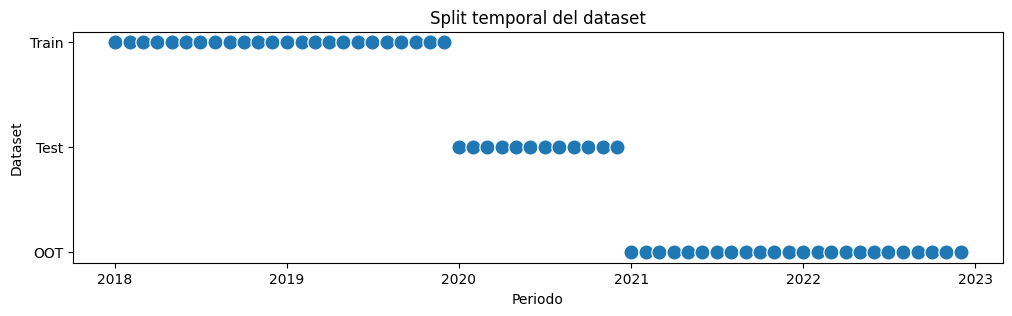

In [109]:
plt.figure(figsize=(12,3))

sns.scatterplot(
    data=timeline,
    x="periodo",
    y="dataset",
    s=120
)

plt.title("Split temporal del dataset")

plt.xlabel("Periodo")
plt.ylabel("Dataset")

plt.show()

## 12. Calcular Gini
Gini = 2*AUC - 1

In [112]:

gini_train = 2*auc_train - 1
gini_test = 2*auc_test - 1
gini_oot = 2*auc_oot - 1

gini_train, gini_test, gini_oot


(0.7769206679887963, 0.7251686773773716, 0.7287219374531446)

## 13. Calcular KS

In [113]:

def ks_stat(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = max(tpr - fpr)
    return ks

ks_train = ks_stat(y_train, train["score"])
ks_test = ks_stat(y_test, test["score"])
ks_oot = ks_stat(y_oot, oot["score"])

ks_train, ks_test, ks_oot


(np.float64(0.6137344838689536),
 np.float64(0.5711156364138752),
 np.float64(0.5715926503144522))

## 14. Crear bandas de riesgo

In [132]:

cuts = train["score"].quantile([0,0.2,0.4,0.6,0.8,1]).values

labels = ["Muy bajo","Bajo","Medio","Alto","Muy alto"]

bins = cuts.copy()

bins[0] = -np.inf
bins[-1] = np.inf

train["risk_band"] = pd.cut(train["score"], bins=bins, labels=labels, include_lowest=True)


In [133]:
cuts

array([0.00111019, 0.00853098, 0.01504572, 0.03082926, 0.08089747,
       0.95410128])

In [134]:
bins

array([      -inf, 0.00853098, 0.01504572, 0.03082926, 0.08089747,
              inf])

In [129]:
train["risk_band"].value_counts()

risk_band
Muy bajo    12000
Bajo        12000
Medio       12000
Alto        12000
Muy alto    12000
Name: count, dtype: int64

## 15. Default rate por banda

In [138]:
summary_table = (
    train
    .groupby("risk_band")
    .agg(
        n_obs=("score","count"),
        n_bad=(target,"sum"),
        bad_rate=(target,"mean"),
        avg_score=("score","mean")
    )
)

summary_table["pct_obs"] = summary_table["n_obs"] / summary_table["n_obs"].sum()

summary_table = summary_table.loc[
    ["Muy alto","Alto","Medio","Bajo","Muy bajo"]
]

summary_table

,n_obs,n_bad,bad_rate,avg_score,pct_obs
risk_band,,,,,
Muy alto,12000,3069.0,0.255750,0.242610,0.2
Alto,12000,563.0,0.046917,0.050910,0.2
Medio,12000,225.0,0.018750,0.021428,0.2
Bajo,12000,109.0,0.009083,0.011546,0.2
Muy bajo,12000,23.0,0.001917,0.005964,0.2


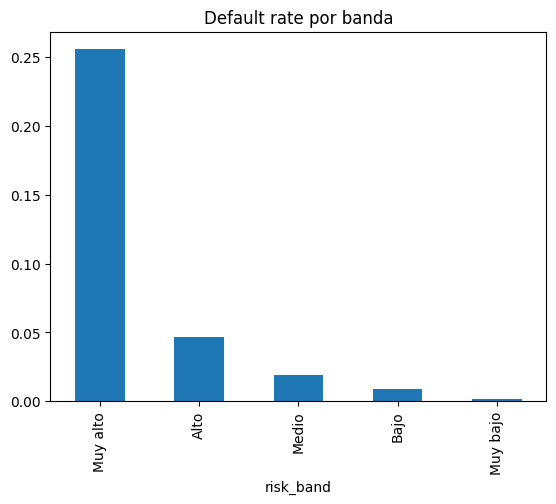

In [140]:
order = ["Muy alto","Alto","Medio","Bajo","Muy bajo"]

train.groupby("risk_band")[target].mean().loc[order].plot(kind="bar")

plt.title("Default rate por banda")

plt.show()


## 16. Lift chart

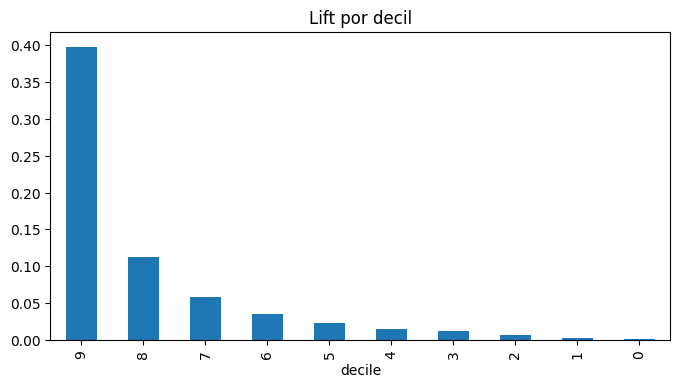

In [141]:

train["decile"] = pd.qcut(train["score"], 10, labels=False)

lift = train.groupby("decile")[target].mean().sort_index(ascending=False)

lift.plot(kind="bar", figsize=(8,4))
plt.title("Lift por decil")
plt.show()


## 17. Guardar artefactos

In [142]:

os.makedirs("artifacts", exist_ok=True)

joblib.dump(model, "artifacts/model.pkl")
joblib.dump(pipeline, "artifacts/pipeline.pkl")

with open("artifacts/features.json","w") as f:
    json.dump(features,f)

with open("artifacts/score_bins.json","w") as f:
    json.dump(bins.tolist(),f)


## 18. Motor de scoring (producción simulada)

In [143]:

def score_production(df_new, artifacts_path="artifacts"):

    model = joblib.load(f"{artifacts_path}/model.pkl")
    pipeline = joblib.load(f"{artifacts_path}/pipeline.pkl")

    with open(f"{artifacts_path}/features.json") as f:
        features = json.load(f)

    with open(f"{artifacts_path}/score_bins.json") as f:
        bins = json.load(f)

    labels = ["Muy bajo","Bajo","Medio","Alto","Muy alto"]

    X = df_new[features]

    X_t = pipeline.transform(X)

    score = model.predict_proba(X_t)[:,1]

    df_new["score"] = score

    df_new["risk_band"] = pd.cut(
        df_new["score"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    return df_new


## 19. Simulación producción en Test

In [144]:

test_scored = score_production(test.copy())
test_scored.head()


/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,dataset,fecha_simulada,periodo,score,periodo_fecha,risk_band
24,25,0.0,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0,train,2020-01-01,202001,0.013137,2020-01-01,Bajo
25,26,1.0,0.392248,50,0,1.595253,4676.0,14,0,3,0,1.0,train,2020-02-01,202002,0.112321,2020-02-01,Muy alto
26,27,0.0,0.052436,58,0,0.097672,8333.0,22,0,1,0,0.0,train,2020-03-01,202003,0.013141,2020-03-01,Bajo
27,28,0.0,0.034421,69,0,0.042383,2500.0,17,0,0,0,1.0,train,2020-04-01,202004,0.012196,2020-04-01,Bajo
28,29,0.0,0.452516,24,0,0.011761,3400.0,1,0,0,0,0.0,train,2020-05-01,202005,0.040233,2020-05-01,Alto


In [145]:
summary_test = (
    test_scored
    .groupby("risk_band")
    .agg(
        n_obs=("score","count"),
        n_bad=(target,"sum"),
        bad_rate=(target,"mean"),
        avg_score=("score","mean")
    )
)

summary_test["pct_obs"] = summary_test["n_obs"] / summary_test["n_obs"].sum()

summary_test = summary_test.loc[
    ["Muy alto","Alto","Medio","Bajo","Muy bajo"]
]

summary_test

,n_obs,n_bad,bad_rate,avg_score,pct_obs
risk_band,,,,,
Muy alto,5852,1453.0,0.248291,0.241527,0.195067
Alto,6108,335.0,0.054846,0.050613,0.203600
Medio,5916,146.0,0.024679,0.021527,0.197200
Bajo,5990,68.0,0.011352,0.011561,0.199667
Muy bajo,6134,29.0,0.004728,0.005941,0.204467


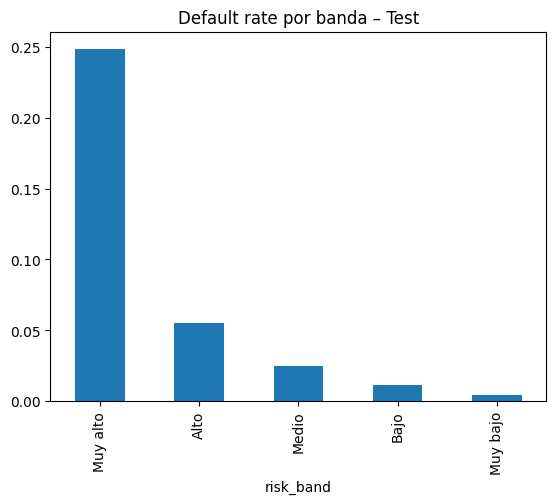

In [146]:
order = ["Muy alto","Alto","Medio","Bajo","Muy bajo"]

bad_rate_test = (
    test_scored
    .groupby("risk_band")[target]
    .mean()
    .loc[order]
)

bad_rate_test.plot(kind="bar")

plt.title("Default rate por banda – Test")

plt.show()

In [147]:
pd.concat(
    [summary_table["bad_rate"], summary_test["bad_rate"]],
    axis=1,
    keys=["Train","Test"]
)

,Train,Test
risk_band,,
Muy alto,0.255750,0.248291
Alto,0.046917,0.054846
Medio,0.018750,0.024679
Bajo,0.009083,0.011352
Muy bajo,0.001917,0.004728


## 20. Simulación producción en OOT

In [121]:

oot_scored = score_production(oot.copy())
oot_scored.head()


/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,dataset,fecha_simulada,periodo,score,periodo_fecha,risk_band
36,37,0.0,0.881836,50,3,0.567858,4000.0,9,0,1,0,1.0,train,2021-01-01,202101,0.306267,2021-01-01,Muy alto
37,38,0.0,1.000000,75,1,0.134078,3400.0,1,0,1,0,1.0,train,2021-02-01,202102,0.080325,2021-02-01,Alto
38,39,0.0,0.363636,26,0,0.009990,1000.0,1,0,0,0,0.0,train,2021-03-01,202103,0.033006,2021-03-01,Alto
39,40,0.0,0.304491,52,0,0.808340,3500.0,10,0,2,0,0.0,train,2021-04-01,202104,0.038785,2021-04-01,Alto
40,41,0.0,0.719985,41,1,0.539554,5700.0,14,0,1,0,0.0,train,2021-05-01,202105,0.170128,2021-05-01,Muy alto


In [173]:
records_period = oot.groupby("periodo").size().reset_index(name="n_registros")

records_period

,periodo,n_registros
0,202101,2500
1,202102,2500
2,202103,2500
3,202104,2500
4,202105,2500
5,202106,2500
6,202107,2500
7,202108,2500
8,202109,2500
9,202110,2500


In [148]:
summary_oot = (
    oot_scored
    .groupby("risk_band")
    .agg(
        n_obs=("score","count"),
        n_bad=(target,"sum"),
        bad_rate=(target,"mean"),
        avg_score=("score","mean")
    )
)

summary_oot["pct_obs"] = summary_oot["n_obs"] / summary_oot["n_obs"].sum()

summary_oot = summary_oot.loc[
    ["Muy alto","Alto","Medio","Bajo","Muy bajo"]
]

summary_oot

,n_obs,n_bad,bad_rate,avg_score,pct_obs
risk_band,,,,,
Muy alto,11851,2889.0,0.243777,0.243034,0.197520
Alto,12320,679.0,0.055114,0.050995,0.205337
Medio,11835,264.0,0.022307,0.021380,0.197253
Bajo,11837,113.0,0.009546,0.011578,0.197287
Muy bajo,12156,60.0,0.004936,0.005983,0.202603


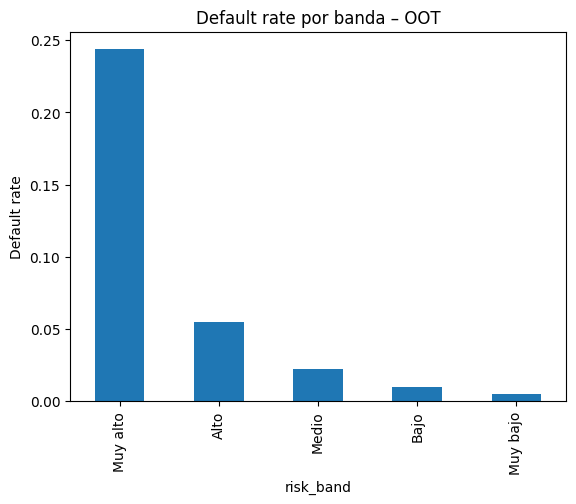

In [149]:
order = ["Muy alto","Alto","Medio","Bajo","Muy bajo"]

bad_rate_oot = (
    oot_scored
    .groupby("risk_band")[target]
    .mean()
    .loc[order]
)

bad_rate_oot.plot(kind="bar")

plt.title("Default rate por banda – OOT")

plt.ylabel("Default rate")

plt.show()

In [150]:
comparison = pd.concat(
    [
        summary_table["bad_rate"],
        summary_test["bad_rate"],
        summary_oot["bad_rate"]
    ],
    axis=1
)

comparison.columns = ["Train","Test","OOT"]

comparison

,Train,Test,OOT
risk_band,,,
Muy alto,0.255750,0.248291,0.243777
Alto,0.046917,0.054846,0.055114
Medio,0.018750,0.024679,0.022307
Bajo,0.009083,0.011352,0.009546
Muy bajo,0.001917,0.004728,0.004936


In [151]:
monthly_perf = (
    oot_scored
    .groupby(["risk_band","periodo"])[target]
    .mean()
    .reset_index()
)

In [152]:
pivot_month = monthly_perf.pivot(
    index="risk_band",
    columns="periodo",
    values=target
)

In [153]:
order = ["Muy alto","Alto","Medio","Bajo","Muy bajo"]

pivot_month = pivot_month.loc[order]

In [154]:
pivot_month

periodo,202101,202102,202103,202104,202105,202106,202107,202108,202109,202110,...,202203,202204,202205,202206,202207,202208,202209,202210,202211,202212
risk_band,,,,,,,,,,,,,,,,,,,,,
Muy alto,0.239216,0.222458,0.256048,0.237354,0.252852,0.253638,0.215321,0.242038,0.265010,0.244444,...,0.267327,0.259036,0.244444,0.247984,0.235521,0.243461,0.224900,0.241176,0.226415,0.273810
Alto,0.042751,0.041176,0.059615,0.055344,0.045082,0.053950,0.066288,0.042553,0.069811,0.056711,...,0.071984,0.046512,0.072016,0.069034,0.057312,0.047228,0.063618,0.044088,0.059322,0.042169
Medio,0.024845,0.024048,0.024793,0.018072,0.037773,0.019651,0.026157,0.021113,0.013187,0.032136,...,0.023656,0.032692,0.023211,0.014403,0.020576,0.032454,0.012605,0.024668,0.014344,0.014553
Bajo,0.015842,0.008403,0.007937,0.016736,0.010121,0.001996,0.008621,0.015873,0.016886,0.008791,...,0.014141,0.010417,0.012422,0.015748,0.008032,0.000000,0.004057,0.006410,0.005618,0.017274
Muy bajo,0.002155,0.005525,0.004032,0.004115,0.002045,0.005545,0.003788,0.002053,0.004008,0.010163,...,0.009597,0.002058,0.005780,0.003976,0.004065,0.005660,0.003774,0.002016,0.007561,0.006048


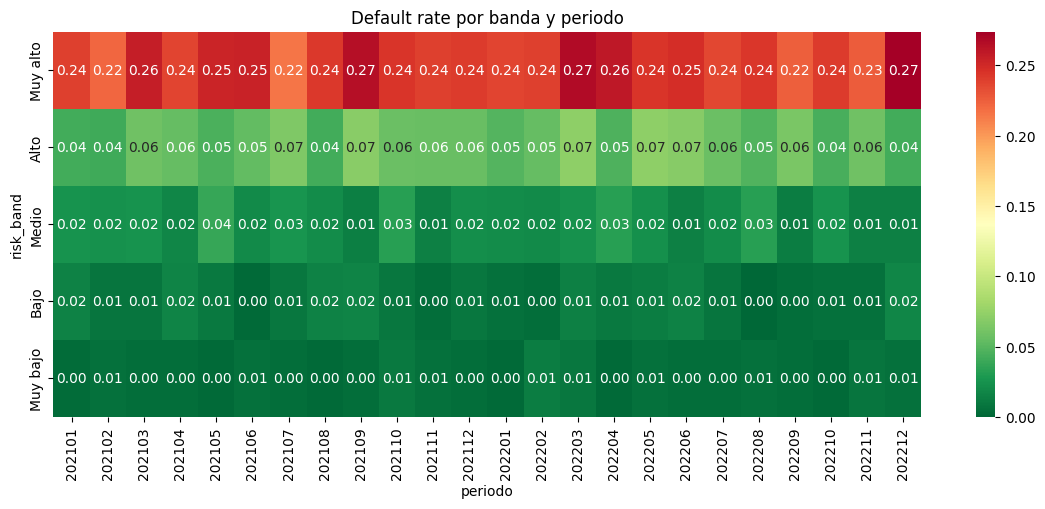

In [155]:
plt.figure(figsize=(14,5))

sns.heatmap(
    pivot_month,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f"
)

plt.title("Default rate por banda y periodo")

plt.show()

In [156]:
pivot_count = (
    oot_scored
    .groupby(["risk_band","periodo"])
    .size()
    .unstack()
)

pivot_count.loc[order]

periodo,202101,202102,202103,202104,202105,202106,202107,202108,202109,202110,...,202203,202204,202205,202206,202207,202208,202209,202210,202211,202212
risk_band,,,,,,,,,,,,,,,,,,,,,
Muy alto,510,472,496,514,526,481,483,471,483,495,...,505,498,495,496,518,497,498,510,477,504
Alto,538,510,520,524,488,519,528,517,530,529,...,514,516,486,507,506,487,503,499,472,498
Medio,483,499,484,498,503,458,497,521,455,529,...,465,520,517,486,486,493,476,527,488,481
Bajo,505,476,504,478,494,501,464,504,533,455,...,495,480,483,508,498,492,493,468,534,521
Muy bajo,464,543,496,486,489,541,528,487,499,492,...,521,486,519,503,492,530,530,496,529,496


In [157]:
train_scored = train.copy()
test_scored = test_scored.copy()
oot_scored = oot_scored.copy()

train_scored["dataset"] = "Train"
test_scored["dataset"] = "Test"
oot_scored["dataset"] = "OOT"

monitor_df = pd.concat([train_scored, test_scored, oot_scored])

In [158]:
monitor_month = (
    monitor_df
    .groupby(["dataset","risk_band","periodo"])[target]
    .mean()
    .reset_index()
)

In [159]:
order = ["Muy alto","Alto","Medio","Bajo","Muy bajo"]

In [160]:
def create_pivot(data, dataset_name):

    pivot = (
        data[data["dataset"] == dataset_name]
        .pivot(index="risk_band", columns="periodo", values=target)
    )

    return pivot.loc[order]

In [161]:
pivot_train = create_pivot(monitor_month, "Train")
pivot_test = create_pivot(monitor_month, "Test")
pivot_oot = create_pivot(monitor_month, "OOT")

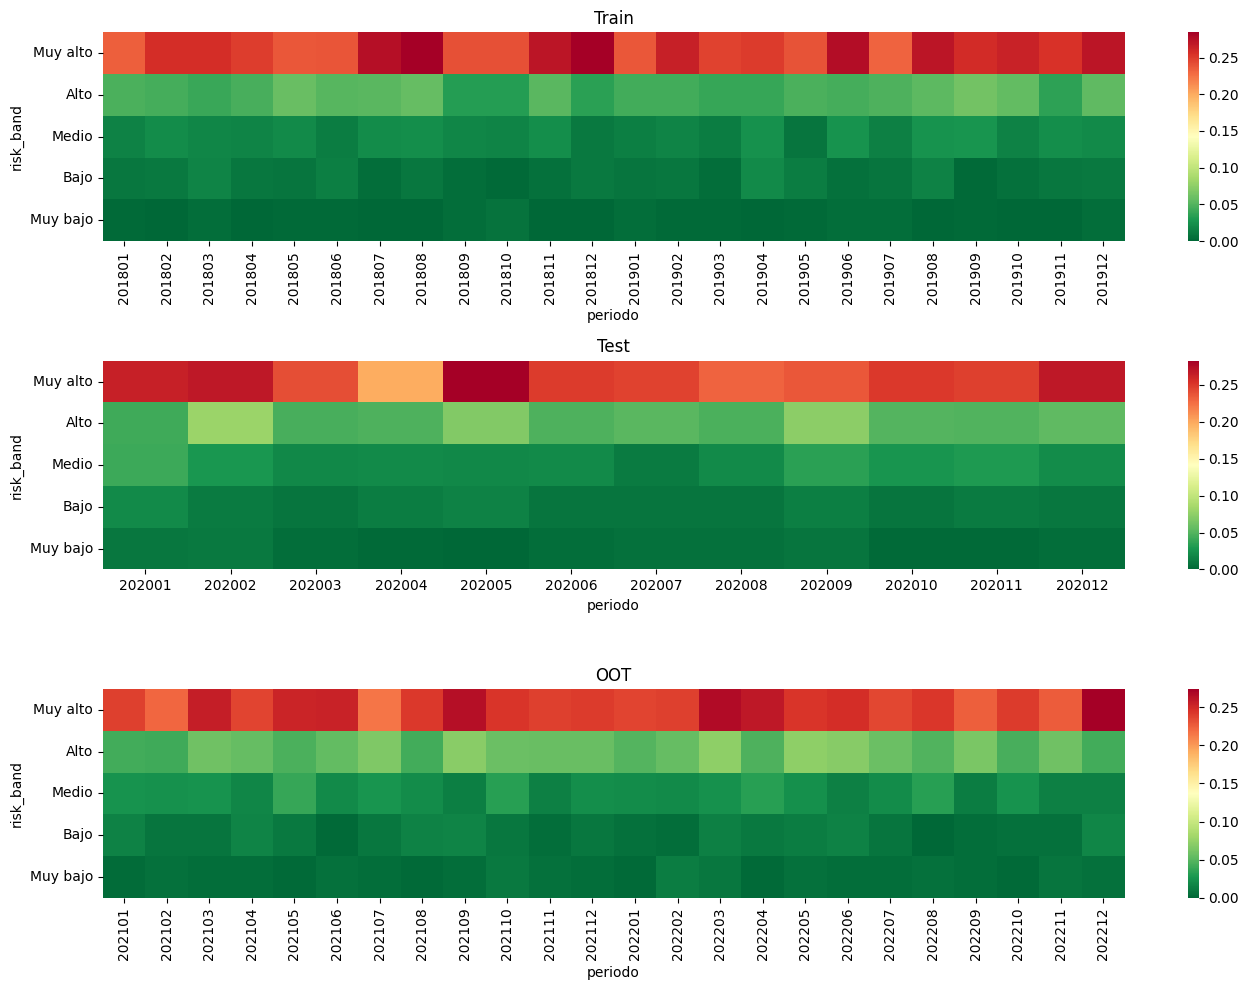

In [162]:
fig, axes = plt.subplots(3,1, figsize=(14,10))

sns.heatmap(pivot_train, cmap="RdYlGn_r", annot=False, ax=axes[0])
axes[0].set_title("Train")

sns.heatmap(pivot_test, cmap="RdYlGn_r", annot=False, ax=axes[1])
axes[1].set_title("Test")

sns.heatmap(pivot_oot, cmap="RdYlGn_r", annot=False, ax=axes[2])
axes[2].set_title("OOT")

plt.tight_layout()

plt.show()

## 21. Score por periodo (monitoring)

In [124]:
oot_scored["periodo_fecha"] = pd.to_datetime(
    oot_scored["periodo"].astype(str),
    format="%Y%m"
)

In [125]:
score_period = (
    oot_scored
    .groupby("periodo_fecha")["score"]
    .mean()
)

## Evolución mensual del Gini

Analizamos cómo evoluciona el desempeño del modelo a lo largo del tiempo.

Calculamos el Gini por periodo para Train, Test y OOT.

In [164]:
def gini_by_month(df):

    result = []

    for p in sorted(df["periodo"].unique()):

        temp = df[df["periodo"] == p]

        if temp[target].nunique() < 2:
            continue

        auc = roc_auc_score(temp[target], temp["score"])
        gini = 2*auc - 1

        result.append({
            "periodo": p,
            "gini": gini
        })

    return pd.DataFrame(result)

In [165]:
gini_train = gini_by_month(train)
gini_test = gini_by_month(test_scored)
gini_oot = gini_by_month(oot_scored)

In [166]:
gini_train["periodo"] = pd.to_datetime(gini_train["periodo"].astype(str), format="%Y%m")
gini_test["periodo"] = pd.to_datetime(gini_test["periodo"].astype(str), format="%Y%m")
gini_oot["periodo"] = pd.to_datetime(gini_oot["periodo"].astype(str), format="%Y%m")

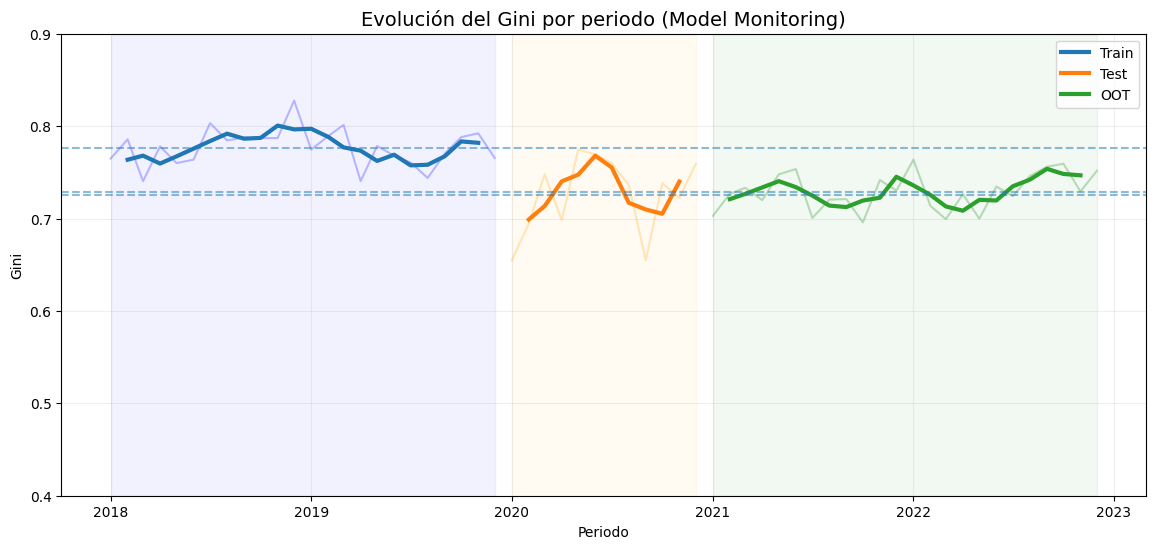

In [172]:
# suavizado
window = 3

gini_train["smooth"] = gini_train["gini"].rolling(window, center=True).mean()
gini_test["smooth"] = gini_test["gini"].rolling(window, center=True).mean()
gini_oot["smooth"] = gini_oot["gini"].rolling(window, center=True).mean()

plt.figure(figsize=(14,6))

# líneas reales (tenues)
plt.plot(gini_train["periodo"], gini_train["gini"], alpha=0.25, color="blue")
plt.plot(gini_test["periodo"], gini_test["gini"], alpha=0.25, color="orange")
plt.plot(gini_oot["periodo"], gini_oot["gini"], alpha=0.25, color="green")

# líneas suavizadas
plt.plot(gini_train["periodo"], gini_train["smooth"], label="Train", linewidth=3)
plt.plot(gini_test["periodo"], gini_test["smooth"], label="Test", linewidth=3)
plt.plot(gini_oot["periodo"], gini_oot["smooth"], label="OOT", linewidth=3)

# líneas de referencia (promedio)
plt.axhline(gini_train["gini"].mean(), linestyle="--", alpha=0.5)
plt.axhline(gini_test["gini"].mean(), linestyle="--", alpha=0.5)
plt.axhline(gini_oot["gini"].mean(), linestyle="--", alpha=0.5)

# sombreado de datasets
plt.axvspan(gini_train["periodo"].min(), gini_train["periodo"].max(), alpha=0.05, color="blue")
plt.axvspan(gini_test["periodo"].min(), gini_test["periodo"].max(), alpha=0.05, color="orange")
plt.axvspan(gini_oot["periodo"].min(), gini_oot["periodo"].max(), alpha=0.05, color="green")

plt.title("Evolución del Gini por periodo (Model Monitoring)", fontsize=14)

plt.xlabel("Periodo")
plt.ylabel("Gini")

plt.ylim(0.4,0.9)

plt.legend()

plt.grid(alpha=0.2)

plt.show()

## 22. Conclusiones
En este notebook construimos un pipeline completo de Machine Learning industrial:
- Train/Test/OOT
- Probabilidad de riesgo
- Bandas de score
- Guardado de artefactos
- Scoring en producción
- Métricas industriales (AUC, Gini, KS, Lift)
- Monitoreo por periodo